# Arctic Domain EDA

Explore inputs and targets for `H1_V10` and `H1_V7`. Answers key questions from `arctic_description.md` before preprocessing.

In [36]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import gcsfs
from IPython.display import display

warnings.filterwarnings('ignore')

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'CLAUDE.md').exists())
sys.path.insert(0, str(root))
from config.config import load_config

cfg    = load_config('arctic_domain')
BUCKET = cfg['gcs']['bucket']
GRIDS  = cfg['gcs']['eda_grids']
SSP1, SSP5 = cfg['scenarios']
SUB    = cfg['gcs']['target_subfolder']

fs = gcsfs.GCSFileSystem(token='google_default')
_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

def open_nc(path):
    bare = path.replace('gs://', '')
    if not fs.exists(bare):
        raise FileNotFoundError(f'Not found: {path}')
    for engine in ('h5netcdf', 'scipy'):
        try:
            with fs.open(path, 'rb') as f:
                return xr.open_dataset(f, engine=engine, decode_times=_coder).load()
        except Exception:
            continue
    raise RuntimeError(f'Cannot open: {path}')

def nan_frac(da):
    return float(da.isnull().mean())

def first_var(ds, min_ndim=1):
    return next(da for da in ds.data_vars.values() if da.ndim >= min_ndim)

def inp(grid, scenario, fname):
    return f'{BUCKET}/{grid}/{scenario}/{fname}'

def tgt(grid, scenario, fname):
    return f'{BUCKET}/{grid}/{scenario}_split/{SUB}/{fname}'

def time_res(ds):
    td = next((d for d in ds.dims if d in ('time', 'year')), None)
    if td is None or len(ds[td]) < 2:
        return 'yearly'
    t = ds[td].values
    try:
        delta = float(np.median(np.diff([v.toordinal() for v in t])))
    except Exception:
        delta = float(np.median(np.diff(t.astype('datetime64[D]').astype(float))))
    return 'monthly' if delta < 50 else 'yearly'

rows = []

## 1. Static Inputs

In [37]:
print('{:<28} {:<8} {:<25} {}'.format('FILE', 'GRID', 'DIMS', 'NAN%'))
print('-' * 70)
for grid in GRIDS:
    for fname in cfg['inputs']['static']:
        ds = open_nc(inp(grid, SSP1, fname))
        da = first_var(ds, min_ndim=2)
        nf = nan_frac(da)
        sp_c = [c for c in ds.coords if c in ('Y', 'X', 'y', 'x')]
        print('{:<28} {:<8} {:<25} {:.1%}  coords={}'.format(
            fname, grid, str(dict(ds.dims)), nf, sp_c))
        rows.append(dict(kind='static', file=fname, grid=grid, scenario='-',
                         dims=str(dict(ds.dims)), resolution='static',
                         t_start=None, t_end=None, n_t=None, nan_frac=f'{nf:.1%}'))

FILE                         GRID     DIMS                      NAN%
----------------------------------------------------------------------
soil-texture.nc              H1_V10   {'Y': 28, 'X': 32}        0.0%  coords=['X', 'Y']
drainage.nc                  H1_V10   {'Y': 28, 'X': 32}        0.0%  coords=['X', 'Y']
fri-fire.nc                  H1_V10   {'Y': 28, 'X': 32}        0.0%  coords=['Y', 'X']
topo.nc                      H1_V10   {'Y': 28, 'X': 32}        0.0%  coords=['X', 'Y']
vegetation.nc                H1_V10   {'Y': 28, 'X': 32}        0.0%  coords=['X', 'Y']
soil-texture.nc              H1_V7    {'Y': 71, 'X': 31}        0.0%  coords=['X', 'Y']
drainage.nc                  H1_V7    {'Y': 71, 'X': 31}        0.0%  coords=['X', 'Y']
fri-fire.nc                  H1_V7    {'Y': 71, 'X': 31}        0.0%  coords=['Y', 'X']
topo.nc                      H1_V7    {'Y': 71, 'X': 31}        0.1%  coords=['X', 'Y']
vegetation.nc                H1_V7    {'Y': 71, 'X': 31}        0.0%

## 2. Dynamic Inputs

In [38]:
# CO2 — time-only; H1_V10 / SSP1 only (same structure across scenarios)
print('CO2 (time-only):')
for fname in cfg['inputs']['dynamic_time_only']:
    ds = open_nc(inp(GRIDS[0], SSP1, fname))
    td = list(ds.dims)[0]
    da = first_var(ds)
    t  = ds[td].values
    print(f'  {fname:<28}  dim={td!r}  n={len(t)}  range=[{t[0]}..{t[-1]}]  sample={da.values[:3].round(2)}')
    rows.append(dict(kind='dynamic', file=fname, grid=GRIDS[0], scenario='ssp1',
                     dims=str(dict(ds.dims)), resolution=f'dim={td!r}',
                     t_start=str(t[0]), t_end=str(t[-1]), n_t=len(t),
                     nan_frac=f'{nan_frac(da):.1%}'))

# Climate + Fire — space x time, both grids x both scenarios
print()
print('{:<32} {:<7} {:<6} {:<8} {:<24} {:<14} {:<14} {}'.format(
    'FILE', 'GRID', 'SCEN', 'RES', 'SHAPE', 'SPATIAL_COORDS', 'CALENDAR', 'NAN%'))
print('-' * 110)
for grid in GRIDS:
    for scen in [SSP1, SSP5]:
        sn = 'ssp1' if 'ssp1' in scen else 'ssp5'
        for fname in cfg['inputs']['dynamic_spatiotemporal']:
            ds   = open_nc(inp(grid, scen, fname))
            res  = time_res(ds)
            da   = first_var(ds, min_ndim=2)
            sp_c = [c for c in ds.coords if c in ('Y', 'X', 'y', 'x')]
            td   = next((d for d in ds.dims if d in ('time', 'year')), None)
            t    = ds[td].values if td else []
            try:
                cal = t[0].calendar
            except Exception:
                cal = 'n/a'
            nf = nan_frac(da)
            print('{:<32} {:<7} {:<6} {:<8} {:<24} {:<14} {:<14} {:.1%}'.format(
                fname, grid, sn, res, str(dict(ds.dims)), str(sp_c), cal, nf))
            rows.append(dict(kind='dynamic', file=fname, grid=grid, scenario=sn,
                             dims=str(dict(ds.dims)), resolution=res,
                             t_start=str(t[0])[:10] if len(t) else None,
                             t_end=str(t[-1])[:10] if len(t) else None,
                             n_t=len(t), nan_frac=f'{nf:.1%}'))

CO2 (time-only):
  co2.nc                        dim='year'  n=124  range=[1901..2024]  sample=[296.6  296.93 297.26]
  projected-co2.nc              dim='year'  n=76  range=[2025..2100]  sample=[428.17 430.65 433.07]

FILE                             GRID    SCEN   RES      SHAPE                    SPATIAL_COORDS CALENDAR       NAN%
--------------------------------------------------------------------------------------------------------------
historic-climate.nc              H1_V10  ssp1   monthly  {'time': 1488, 'Y': 28, 'X': 32} ['Y', 'X']     noleap         44.6%
projected-climate.nc             H1_V10  ssp1   monthly  {'time': 912, 'Y': 28, 'X': 32} ['Y', 'X']     noleap         44.6%
historic-explicit-fire.nc        H1_V10  ssp1   yearly   {'time': 124, 'Y': 28, 'X': 32} ['Y', 'X']     noleap         0.0%
projected-explicit-fire.nc       H1_V10  ssp1   yearly   {'time': 76, 'Y': 28, 'X': 32} ['Y', 'X']     noleap         0.0%
historic-climate.nc              H1_V10  ssp5   monthly

## 3. Targets

In [39]:
print('{:<6} {:<7} {:<8} {:<6} {:<26} {:<36} {:<14} {}'.format(
    'VAR', 'PERIOD', 'GRID', 'SCEN', 'SHAPE', 'TIME_RANGE', 'COORDS', 'NAN%'))
print('-' * 107)
for t_cfg in cfg['targets']:
    for period, fkey, scens in [
        ('hist', 'historical', [SSP1]),
        ('proj', 'projected',  [SSP1, SSP5]),
    ]:
        for scen in scens:
            sn = 'ssp1' if 'ssp1' in scen else 'ssp5'
            for grid in GRIDS:
                try:
                    ds = open_nc(tgt(grid, scen, t_cfg[fkey]))
                except FileNotFoundError:
                    print('{:<6} {:<7} {:<8} {:<6}  NOT FOUND'.format(
                        t_cfg['name'], period, grid, sn))
                    continue
                da   = first_var(ds, min_ndim=2)
                td   = next((d for d in da.dims if d in ('time', 'year')), None)
                t    = ds[td].values if td else []
                sp_c = [c for c in ds.coords if c in ('Y', 'X', 'y', 'x')]
                nf   = nan_frac(da)
                t_range = f'{str(t[0])[:10]}..{str(t[-1])[:10]}' if len(t) else '?'
                flag = ''
                if period == 'proj' and t_cfg['resolution'] == 'yearly' and len(t):
                    try:
                        if t[0].year < 2000:
                            flag = f'  *** WRONG LABELS: {str(t[0])[:10]}..{str(t[-1])[:10]}'
                    except Exception:
                        pass
                name = t_cfg['name']
                print('{:<6} {:<7} {:<8} {:<6} {:<26} {:<36} {:<14} {:.1%}{}'.format(
                    name, period, grid, sn,
                    str(dict(ds.dims)), t_range, str(sp_c), nf, flag))
                rows.append(dict(kind='target', file=t_cfg[fkey], grid=grid, scenario=sn,
                                 variable=name, period=period,
                                 dims=str(dict(ds.dims)), resolution=t_cfg['resolution'],
                                 t_start=str(t[0])[:10] if len(t) else None,
                                 t_end=str(t[-1])[:10] if len(t) else None,
                                 n_t=len(t), nan_frac=f'{nf:.1%}'))

VAR    PERIOD  GRID     SCEN   SHAPE                      TIME_RANGE                           COORDS         NAN%
-----------------------------------------------------------------------------------------------------------
ALD    hist    H1_V10   ssp1   {'time': 124, 'y': 28, 'x': 32} 1901-01-01..2024-01-01               []             44.6%
ALD    hist    H1_V7    ssp1   {'time': 124, 'y': 71, 'x': 31} 1901-01-01..2024-01-01               []             32.6%
ALD    proj    H1_V10   ssp1   {'time': 76, 'y': 28, 'x': 32} 1901-01-01..1976-01-01               []             44.6%  *** WRONG LABELS: 1901-01-01..1976-01-01
ALD    proj    H1_V7    ssp1   {'time': 76, 'y': 71, 'x': 31} 1901-01-01..1976-01-01               []             32.6%  *** WRONG LABELS: 1901-01-01..1976-01-01
ALD    proj    H1_V10   ssp5   {'time': 76, 'y': 28, 'x': 32} 1901-01-01..1976-01-01               []             44.6%  *** WRONG LABELS: 1901-01-01..1976-01-01
ALD    proj    H1_V7    ssp5   {'time': 76, 'y': 

## 4. NaN Heatmaps

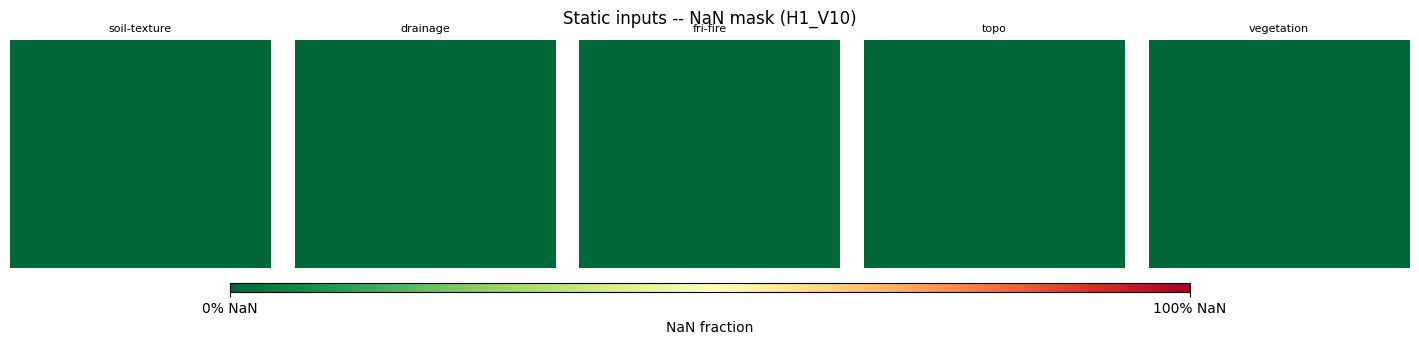

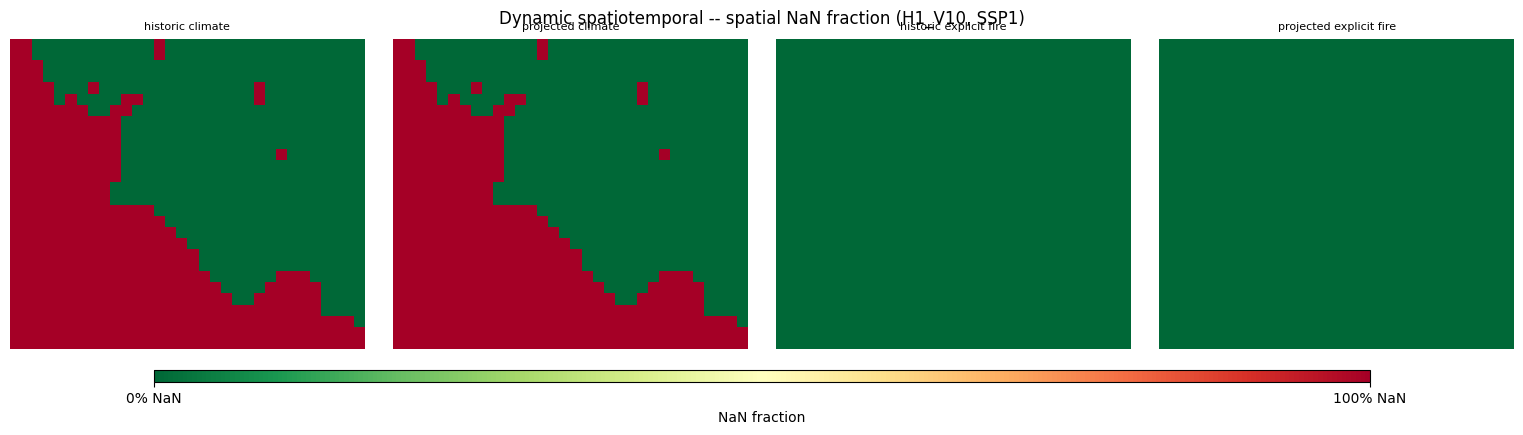

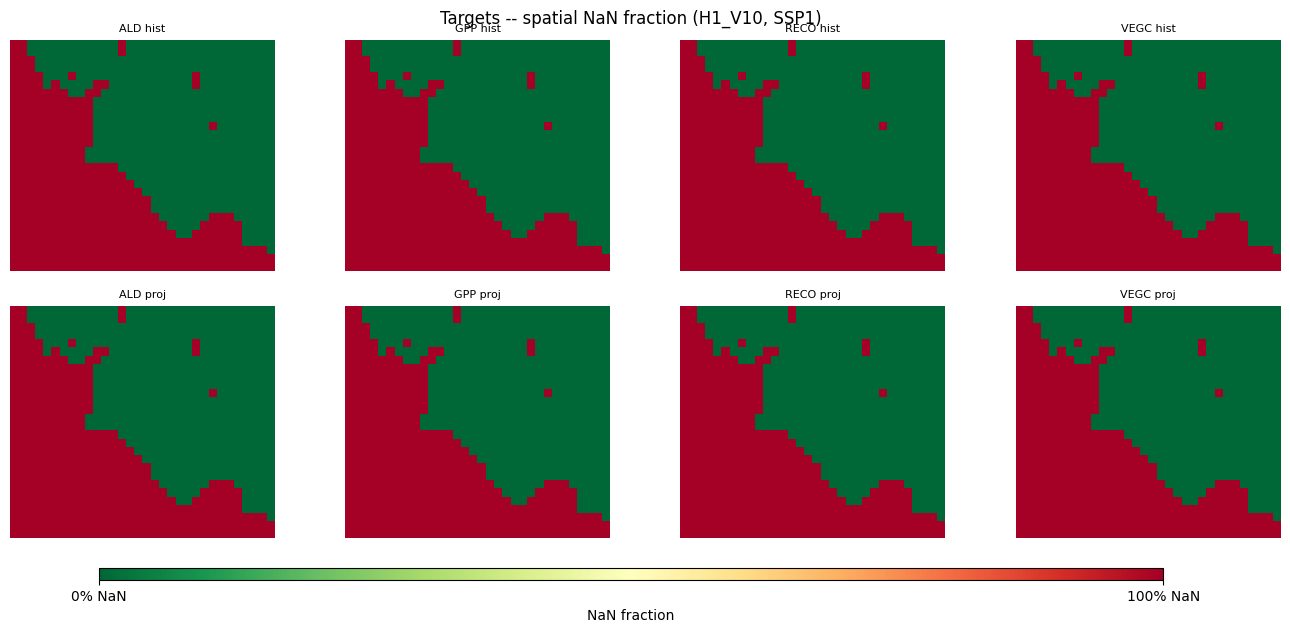

In [40]:
G, SC = GRIDS[0], SSP1

def nan_map(ds):
    da = first_var(ds, min_ndim=2)
    time_dims = [d for d in da.dims if d in ('time', 'year')]
    return da.isnull().mean(dim=time_dims).values if time_dims else da.isnull().values

def _first_image(axes):
    for ax in (axes.flatten() if hasattr(axes, 'flatten') else axes):
        if getattr(ax, 'images', None):
            return ax.images[0]
    raise RuntimeError('No image found to attach colorbar')

# Static (1x5)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, fname in zip(axes, cfg['inputs']['static']):
    ax.imshow(nan_map(open_nc(inp(G, SC, fname))), cmap='RdYlGn_r', vmin=0, vmax=1)
    ax.set_title(fname.replace('.nc', ''), fontsize=8); ax.axis('off')
fig.suptitle('Static inputs -- NaN mask (H1_V10)')
fig.subplots_adjust(top=0.88, bottom=0.12, left=0.03, right=0.97, wspace=0.05)
cax = fig.add_axes([0.18, 0.04, 0.64, 0.03])
cbar = fig.colorbar(_first_image(axes), cax=cax, orientation='horizontal')
cbar.set_ticks([0, 1]); cbar.set_ticklabels(['0% NaN', '100% NaN']); cbar.set_label('NaN fraction')
plt.show()

# Climate + Fire (1x4)
dyn_files = ['historic-climate.nc', 'projected-climate.nc',
             'historic-explicit-fire.nc', 'projected-explicit-fire.nc']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, fname in zip(axes, dyn_files):
    ax.imshow(nan_map(open_nc(inp(G, SC, fname))), cmap='RdYlGn_r', vmin=0, vmax=1)
    ax.set_title(fname.replace('.nc', '').replace('-', ' '), fontsize=8); ax.axis('off')
fig.suptitle('Dynamic spatiotemporal -- spatial NaN fraction (H1_V10, SSP1)')
fig.subplots_adjust(top=0.92, bottom=0.12, left=0.03, right=0.97, wspace=0.08)
cax = fig.add_axes([0.12, 0.05, 0.76, 0.03])
cbar = fig.colorbar(_first_image(axes), cax=cax, orientation='horizontal')
cbar.set_ticks([0, 1]); cbar.set_ticklabels(['0% NaN', '100% NaN']); cbar.set_label('NaN fraction')
plt.show()

# Targets (2x4: rows=hist/proj, cols=ALD/GPP/RECO/VEGC)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for col, t_cfg in enumerate(cfg['targets']):
    name = t_cfg['name']
    for row, (period, fkey) in enumerate([('hist', 'historical'), ('proj', 'projected')]):
        ax = axes[row, col]
        try:
            ax.imshow(nan_map(open_nc(tgt(G, SC, t_cfg[fkey]))), cmap='RdYlGn_r', vmin=0, vmax=1)
        except Exception:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{name} {period}', fontsize=8); ax.axis('off')
fig.suptitle('Targets -- spatial NaN fraction (H1_V10, SSP1)')
fig.subplots_adjust(top=0.93, bottom=0.10, left=0.04, right=0.98, hspace=0.15, wspace=0.08)
cax = fig.add_axes([0.12, 0.03, 0.76, 0.02])
cbar = fig.colorbar(_first_image(axes), cax=cax, orientation='horizontal')
cbar.set_ticks([0, 1]); cbar.set_ticklabels(['0% NaN', '100% NaN']); cbar.set_label('NaN fraction')
plt.show()

## 5. Correlation -- Dynamic Inputs vs Targets

In [41]:
G, SC = GRIDS[0], SSP1

def sp_mean_ts(ds):
    da = first_var(ds, min_ndim=1)
    td = next((d for d in da.dims if d in ('time', 'year')), da.dims[0])
    sp = [d for d in da.dims if d != td]
    return da.mean(dim=sp, skipna=True).values, ds[td].values

def trim_corr(x, y):
    n = min(len(x), len(y))
    xv, yv = x[:n], y[:n]
    m = ~(np.isnan(xv) | np.isnan(yv))
    return float(np.corrcoef(xv[m], yv[m])[0, 1]) if m.sum() >= 5 else np.nan

def to_yearly_mean(ts, monthly_times):
    years = np.array([v.year for v in monthly_times])
    unique_yrs = np.unique(years)
    return np.array([ts[years == yr].mean() for yr in unique_yrs]), unique_yrs

# Load historical data
ds_clim = open_nc(inp(G, SC, 'historic-climate.nc'))
ds_gpp  = open_nc(tgt(G, SC, 'GPP_monthly_tr.nc'))
ds_reco = open_nc(tgt(G, SC, 'RECO_monthly_tr.nc'))
ds_ald  = open_nc(tgt(G, SC, 'ALD_yearly_tr.nc'))
ds_vegc = open_nc(tgt(G, SC, 'VEGC_yearly_tr.nc'))
ds_co2  = open_nc(inp(G, SC, 'co2.nc'))
ds_fire = open_nc(inp(G, SC, 'historic-explicit-fire.nc'))

gpp_ts,  gpp_t  = sp_mean_ts(ds_gpp)
reco_ts, reco_t = sp_mean_ts(ds_reco)
ald_ts,  _      = sp_mean_ts(ds_ald)
vegc_ts, _      = sp_mean_ts(ds_vegc)
co2_ts,  co2_t  = sp_mean_ts(ds_co2)
fire_ts, fire_t = sp_mean_ts(ds_fire)

# Forward-fill CO2 yearly -> monthly
co2_yrs     = np.array([v.year for v in co2_t]) if hasattr(co2_t[0], 'year') else co2_t.astype(int)
co2_dict    = dict(zip(co2_yrs, co2_ts))
gpp_yrs     = np.array([v.year for v in gpp_t])
co2_monthly = np.array([co2_dict.get(y, np.nan) for y in gpp_yrs])

# Forward-fill fire yearly -> monthly
fire_yrs     = np.array([v.year for v in fire_t]) if hasattr(fire_t[0], 'year') else fire_t.astype(int)
fire_dict    = dict(zip(fire_yrs, fire_ts))
fire_monthly = np.array([fire_dict.get(y, np.nan) for y in gpp_yrs])

# Climate variables excluding coordinate metadata
clim_vars = [v for v in ds_clim.data_vars if ds_clim[v].ndim >= 2 and v not in ('lat', 'lon')]

# Yearly means of monthly climate vars (for correlation with yearly targets)
clim_yr_ts = {}
for var in clim_vars:
    ts, _ = sp_mean_ts(ds_clim[[var]])
    clim_yr_ts[var], _ = to_yearly_mean(ts, gpp_t)

# Build (n_inputs x 4) correlation matrix
input_vars   = clim_vars + ['co2', 'fire']
input_labels = [f'{v}(monthly)' for v in clim_vars] + ['co2(yearly)', 'fire(yearly)']
n_inputs     = len(input_vars)
col_names    = ['GPP(monthly)', 'RECO(monthly)', 'ALD(yearly)', 'VEGC(yearly)']

r_matrix = np.full((n_inputs, 4), np.nan)
for i, name in enumerate(input_vars):
    if name == 'co2':
        m_ts, y_ts = co2_monthly, co2_ts
    elif name == 'fire':
        m_ts, y_ts = fire_monthly, fire_ts
    else:
        m_ts, _ = sp_mean_ts(ds_clim[[name]])
        y_ts    = clim_yr_ts[name]
    r_matrix[i, 0] = trim_corr(m_ts, gpp_ts)
    r_matrix[i, 1] = trim_corr(m_ts, reco_ts)
    r_matrix[i, 2] = trim_corr(y_ts, ald_ts)
    r_matrix[i, 3] = trim_corr(y_ts, vegc_ts)

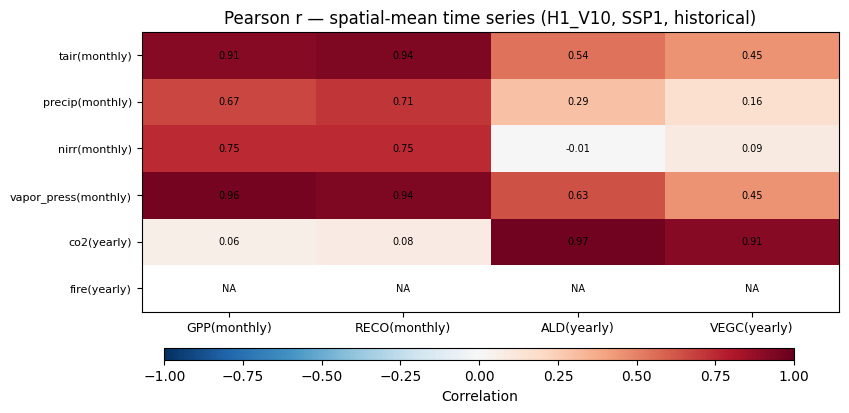

In [42]:
fig, ax = plt.subplots(figsize=(9, max(4, n_inputs * 0.45)))
im = ax.imshow(r_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(4)); ax.set_xticklabels(col_names, fontsize=9)
ax.set_yticks(range(n_inputs)); ax.set_yticklabels(input_labels, fontsize=8)

for i in range(n_inputs):
    for j in range(4):
        v = r_matrix[i, j]
        ax.text(j, i, 'NA' if np.isnan(v) else f'{v:.2f}',
                ha='center', va='center', fontsize=7)

ax.set_title('Pearson r — spatial-mean time series (H1_V10, SSP1, historical)')
fig.subplots_adjust(bottom=0.18)
cax = fig.add_axes([0.15, 0.06, 0.70, 0.03])
fig.colorbar(im, cax=cax, orientation='horizontal', label='Correlation')
plt.show()

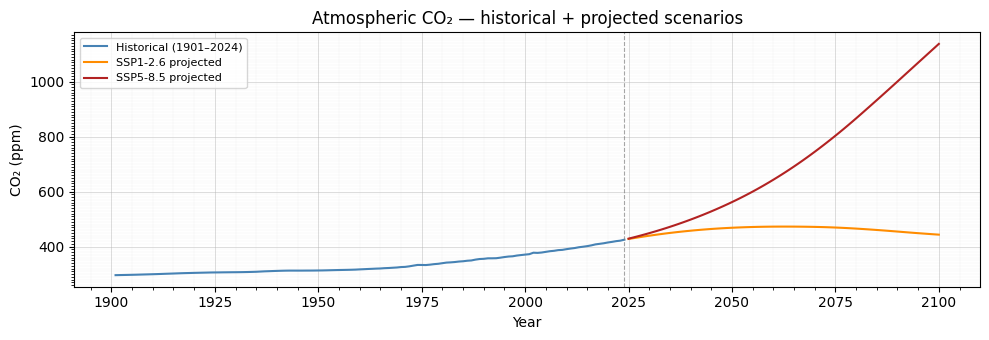

In [43]:
# CO2 time series — historical + projected (SSP1 and SSP5)
ds_proj_ssp1 = open_nc(inp(G, SSP1, 'projected-co2.nc'))
ds_proj_ssp5 = open_nc(inp(G, SSP5, 'projected-co2.nc'))

proj_ts_ssp1, proj_t_ssp1 = sp_mean_ts(ds_proj_ssp1)
proj_ts_ssp5, proj_t_ssp5 = sp_mean_ts(ds_proj_ssp5)

proj_yrs_ssp1 = np.array([v.year for v in proj_t_ssp1]) if hasattr(proj_t_ssp1[0], 'year') else proj_t_ssp1.astype(int)
proj_yrs_ssp5 = np.array([v.year for v in proj_t_ssp5]) if hasattr(proj_t_ssp5[0], 'year') else proj_t_ssp5.astype(int)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(co2_yrs, co2_ts, color='steelblue', lw=1.5, label='Historical (1901–2024)')
ax.plot(proj_yrs_ssp1, proj_ts_ssp1, color='darkorange', lw=1.5, label='SSP1-2.6 projected')
ax.plot(proj_yrs_ssp5, proj_ts_ssp5, color='firebrick', lw=1.5, label='SSP5-8.5 projected')
ax.axvline(2024, color='gray', lw=0.8, ls='--', alpha=0.7)

ax.set_xlabel('Year')
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Atmospheric CO₂ — historical + projected scenarios')
ax.legend(fontsize=8, loc='upper left')

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.4)
ax.xaxis.set_major_locator(plt.MultipleLocator(25))
ax.xaxis.set_minor_locator(plt.MultipleLocator(5))
ax.yaxis.set_minor_locator(plt.MultipleLocator(10))

fig.tight_layout()
plt.show()

## 6. Summary Tables

In [44]:
df = pd.DataFrame(rows)
STATIC_COLS = ['file', 'grid', 'dims', 'nan_frac']
DYN_COLS    = ['file', 'grid', 'scenario', 'dims', 'resolution', 't_start', 't_end', 'n_t', 'nan_frac']
TGT_COLS    = ['variable', 'file', 'grid', 'scenario', 'period', 'dims',
               'resolution', 't_start', 't_end', 'n_t', 'nan_frac']

print('Static Inputs')
display(df[df.kind == 'static'][STATIC_COLS].reset_index(drop=True))
print('\nDynamic Inputs')
display(df[df.kind == 'dynamic'][DYN_COLS].reset_index(drop=True))
print('\nTargets')
display(df[df.kind == 'target'][TGT_COLS].reset_index(drop=True))

Static Inputs


,file,grid,dims,nan_frac
0,soil-texture.nc,H1_V10,"{'Y': 28, 'X': 32}",0.0%
1,drainage.nc,H1_V10,"{'Y': 28, 'X': 32}",0.0%
2,fri-fire.nc,H1_V10,"{'Y': 28, 'X': 32}",0.0%
3,topo.nc,H1_V10,"{'Y': 28, 'X': 32}",0.0%
4,vegetation.nc,H1_V10,"{'Y': 28, 'X': 32}",0.0%
5,soil-texture.nc,H1_V7,"{'Y': 71, 'X': 31}",0.0%
6,drainage.nc,H1_V7,"{'Y': 71, 'X': 31}",0.0%
7,fri-fire.nc,H1_V7,"{'Y': 71, 'X': 31}",0.0%
8,topo.nc,H1_V7,"{'Y': 71, 'X': 31}",0.1%
9,vegetation.nc,H1_V7,"{'Y': 71, 'X': 31}",0.0%



Dynamic Inputs


,file,grid,scenario,dims,resolution,t_start,t_end,n_t,nan_frac
0,co2.nc,H1_V10,ssp1,{'year': 124},dim='year',1901,2024,124.0,0.0%
1,projected-co2.nc,H1_V10,ssp1,{'year': 76},dim='year',2025,2100,76.0,0.0%
2,historic-climate.nc,H1_V10,ssp1,"{'time': 1488, 'Y': 28, 'X': 32}",monthly,1901-01-01,2024-12-01,1488.0,44.6%
3,projected-climate.nc,H1_V10,ssp1,"{'time': 912, 'Y': 28, 'X': 32}",monthly,2025-01-01,2100-12-01,912.0,44.6%
4,historic-explicit-fire.nc,H1_V10,ssp1,"{'time': 124, 'Y': 28, 'X': 32}",yearly,1901-01-01,2024-01-01,124.0,0.0%
5,projected-explicit-fire.nc,H1_V10,ssp1,"{'time': 76, 'Y': 28, 'X': 32}",yearly,2025-01-01,2100-01-01,76.0,0.0%
6,historic-climate.nc,H1_V10,ssp5,"{'time': 1488, 'Y': 28, 'X': 32}",monthly,1901-01-01,2024-12-01,1488.0,44.6%
7,projected-climate.nc,H1_V10,ssp5,"{'time': 912, 'Y': 28, 'X': 32}",monthly,2025-01-01,2100-12-01,912.0,44.6%
8,historic-explicit-fire.nc,H1_V10,ssp5,"{'time': 124, 'Y': 28, 'X': 32}",yearly,1901-01-01,2024-01-01,124.0,0.0%
9,projected-explicit-fire.nc,H1_V10,ssp5,"{'time': 76, 'Y': 28, 'X': 32}",yearly,2025-01-01,2100-01-01,76.0,0.0%



Targets


,variable,file,grid,scenario,period,dims,resolution,t_start,t_end,n_t,nan_frac
0,ALD,ALD_yearly_tr.nc,H1_V10,ssp1,hist,"{'time': 124, 'y': 28, 'x': 32}",yearly,1901-01-01,2024-01-01,124.0,44.6%
1,ALD,ALD_yearly_tr.nc,H1_V7,ssp1,hist,"{'time': 124, 'y': 71, 'x': 31}",yearly,1901-01-01,2024-01-01,124.0,32.6%
2,ALD,ALD_yearly_sc.nc,H1_V10,ssp1,proj,"{'time': 76, 'y': 28, 'x': 32}",yearly,1901-01-01,1976-01-01,76.0,44.6%
3,ALD,ALD_yearly_sc.nc,H1_V7,ssp1,proj,"{'time': 76, 'y': 71, 'x': 31}",yearly,1901-01-01,1976-01-01,76.0,32.6%
4,ALD,ALD_yearly_sc.nc,H1_V10,ssp5,proj,"{'time': 76, 'y': 28, 'x': 32}",yearly,1901-01-01,1976-01-01,76.0,44.6%
5,ALD,ALD_yearly_sc.nc,H1_V7,ssp5,proj,"{'time': 76, 'y': 71, 'x': 31}",yearly,1901-01-01,1976-01-01,76.0,32.6%
6,GPP,GPP_monthly_tr.nc,H1_V10,ssp1,hist,"{'time': 1488, 'y': 28, 'x': 32}",monthly,1901-01-01,2024-12-01,1488.0,44.6%
7,GPP,GPP_monthly_tr.nc,H1_V7,ssp1,hist,"{'time': 1488, 'y': 71, 'x': 31}",monthly,1901-01-01,2024-12-01,1488.0,32.6%
8,GPP,GPP_monthly_sc.nc,H1_V10,ssp1,proj,"{'time': 912, 'y': 28, 'x': 32}",monthly,2025-01-01,2100-12-01,912.0,44.6%
9,GPP,GPP_monthly_sc.nc,H1_V7,ssp1,proj,"{'time': 912, 'y': 71, 'x': 31}",monthly,2025-01-01,2100-12-01,912.0,32.6%


## 7. Key Findings

*Fill in after running all cells above.*

- **CO2:** dim=`year` with integer values (124 hist steps, 76 proj steps) -- yearly resolution confirmed. Include or exclude based on correlation above.
- **Climate:** [calendar type observed; monthly cadence confirmed?]
- **Fire:** yearly resolution confirmed (12-month gap at hist/proj join). Include or exclude based on correlation above.
- **Projected yearly target labels:** ALD and VEGC projected show labels 1901-01-01..1976-01-01 instead of expected 2025-2100 -- wrong labels confirmed.
- **Coordinate naming:** static and dynamic inputs use uppercase `Y`/`X`; targets use lowercase `y`/`x` -- normalise in preprocessing.
- **Ocean pixels:** ~42% NaN in H1_V10 vegetation.nc, ~30% in H1_V7 -- drop pixels where all targets are NaN.

### Per-file descriptions

*Brief paragraph for each file. Fill in after reviewing outputs above.*

**soil-texture.nc:**

**drainage.nc:**

**fri-fire.nc:**

**topo.nc:**

**vegetation.nc:**

**co2.nc / projected-co2.nc:**

**historic-climate.nc / projected-climate.nc:**

**historic-explicit-fire.nc / projected-explicit-fire.nc:**

**GPP_monthly_tr/sc.nc:**

**RECO_monthly_tr/sc.nc:**

**ALD_yearly_tr/sc.nc:**

**VEGC_yearly_tr/sc.nc:**